In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set_style("darkgrid")
sns.set_palette("Set2")

In [32]:
data=pd.read_csv(r"D:\Downloads\data sets\train.csv")

In [33]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [34]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [35]:
print(data.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [36]:
data.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

In [37]:
data.info

<bound method DataFrame.info of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Ut

In [38]:
data.isnull().sum().sort_values(ascending=True)

Id                  0
TotalBsmtSF         0
Heating             0
SaleCondition       0
CentralAir          0
                 ... 
MasVnrType        872
Fence            1179
Alley            1369
MiscFeature      1406
PoolQC           1453
Length: 81, dtype: int64

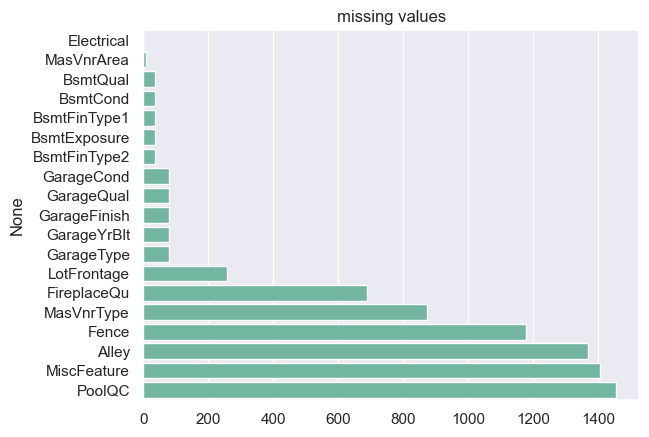

In [57]:
n=data.isnull().sum()
n=n[n>0].sort_values(ascending=True)
plt.title("missing values")
sns.barplot(x=n.values,y=n.index,)
plt.show()

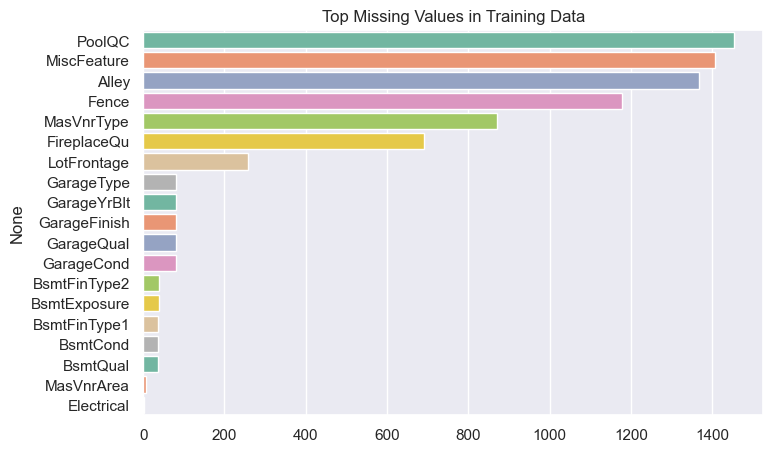

In [64]:
import warnings
warnings.filterwarnings('ignore')
missing = data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=missing.values, y=missing.index, palette="Set2")
plt.title("Top Missing Values in Training Data")
plt.show()

<Axes: xlabel='SalePrice', ylabel='Count'>

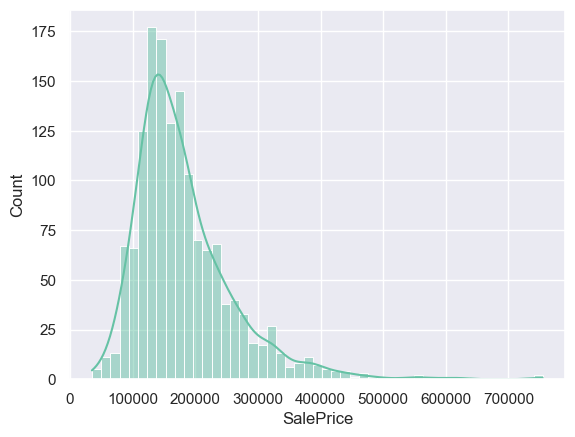

In [70]:
sns.histplot(x=data.SalePrice,kde=True,palette='Set2')

In [71]:
# fill missing value
for i in data.columns:
    if data[i].dtypes=="object":
        data[i]=data[i].fillna(data[i].mode())
    else:
        data[i]=data[i].fillna(data[i].median())

In [72]:
data.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [83]:
correlation=data.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
top_10=correlation.index[1:11]
print("Top 10 Drivers of House Price:")
print(correlation[1:11])

Top 10 Drivers of House Price:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [81]:
top_10

Index(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF',
       '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd'],
      dtype='object')

In [84]:
data.OverallQual

0       7
1       6
2       7
3       7
4       8
       ..
1455    6
1456    6
1457    7
1458    5
1459    5
Name: OverallQual, Length: 1460, dtype: int64

In [95]:
data=data.drop_duplicates()

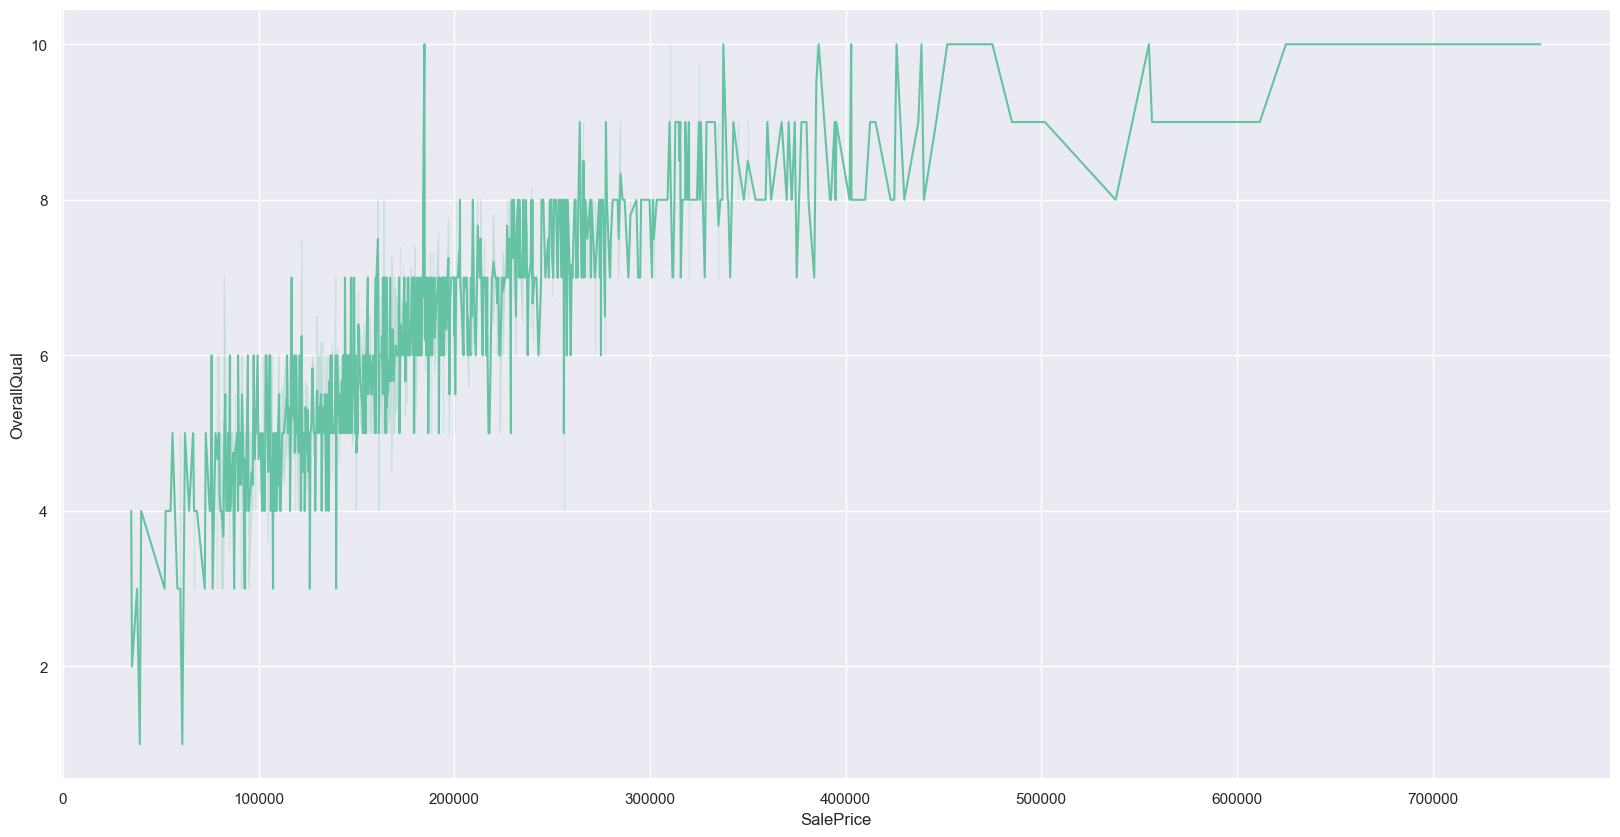

In [96]:
plt.figure(figsize=(20,10))
sns.lineplot(x="SalePrice",y="OverallQual",data=data)
plt.show()

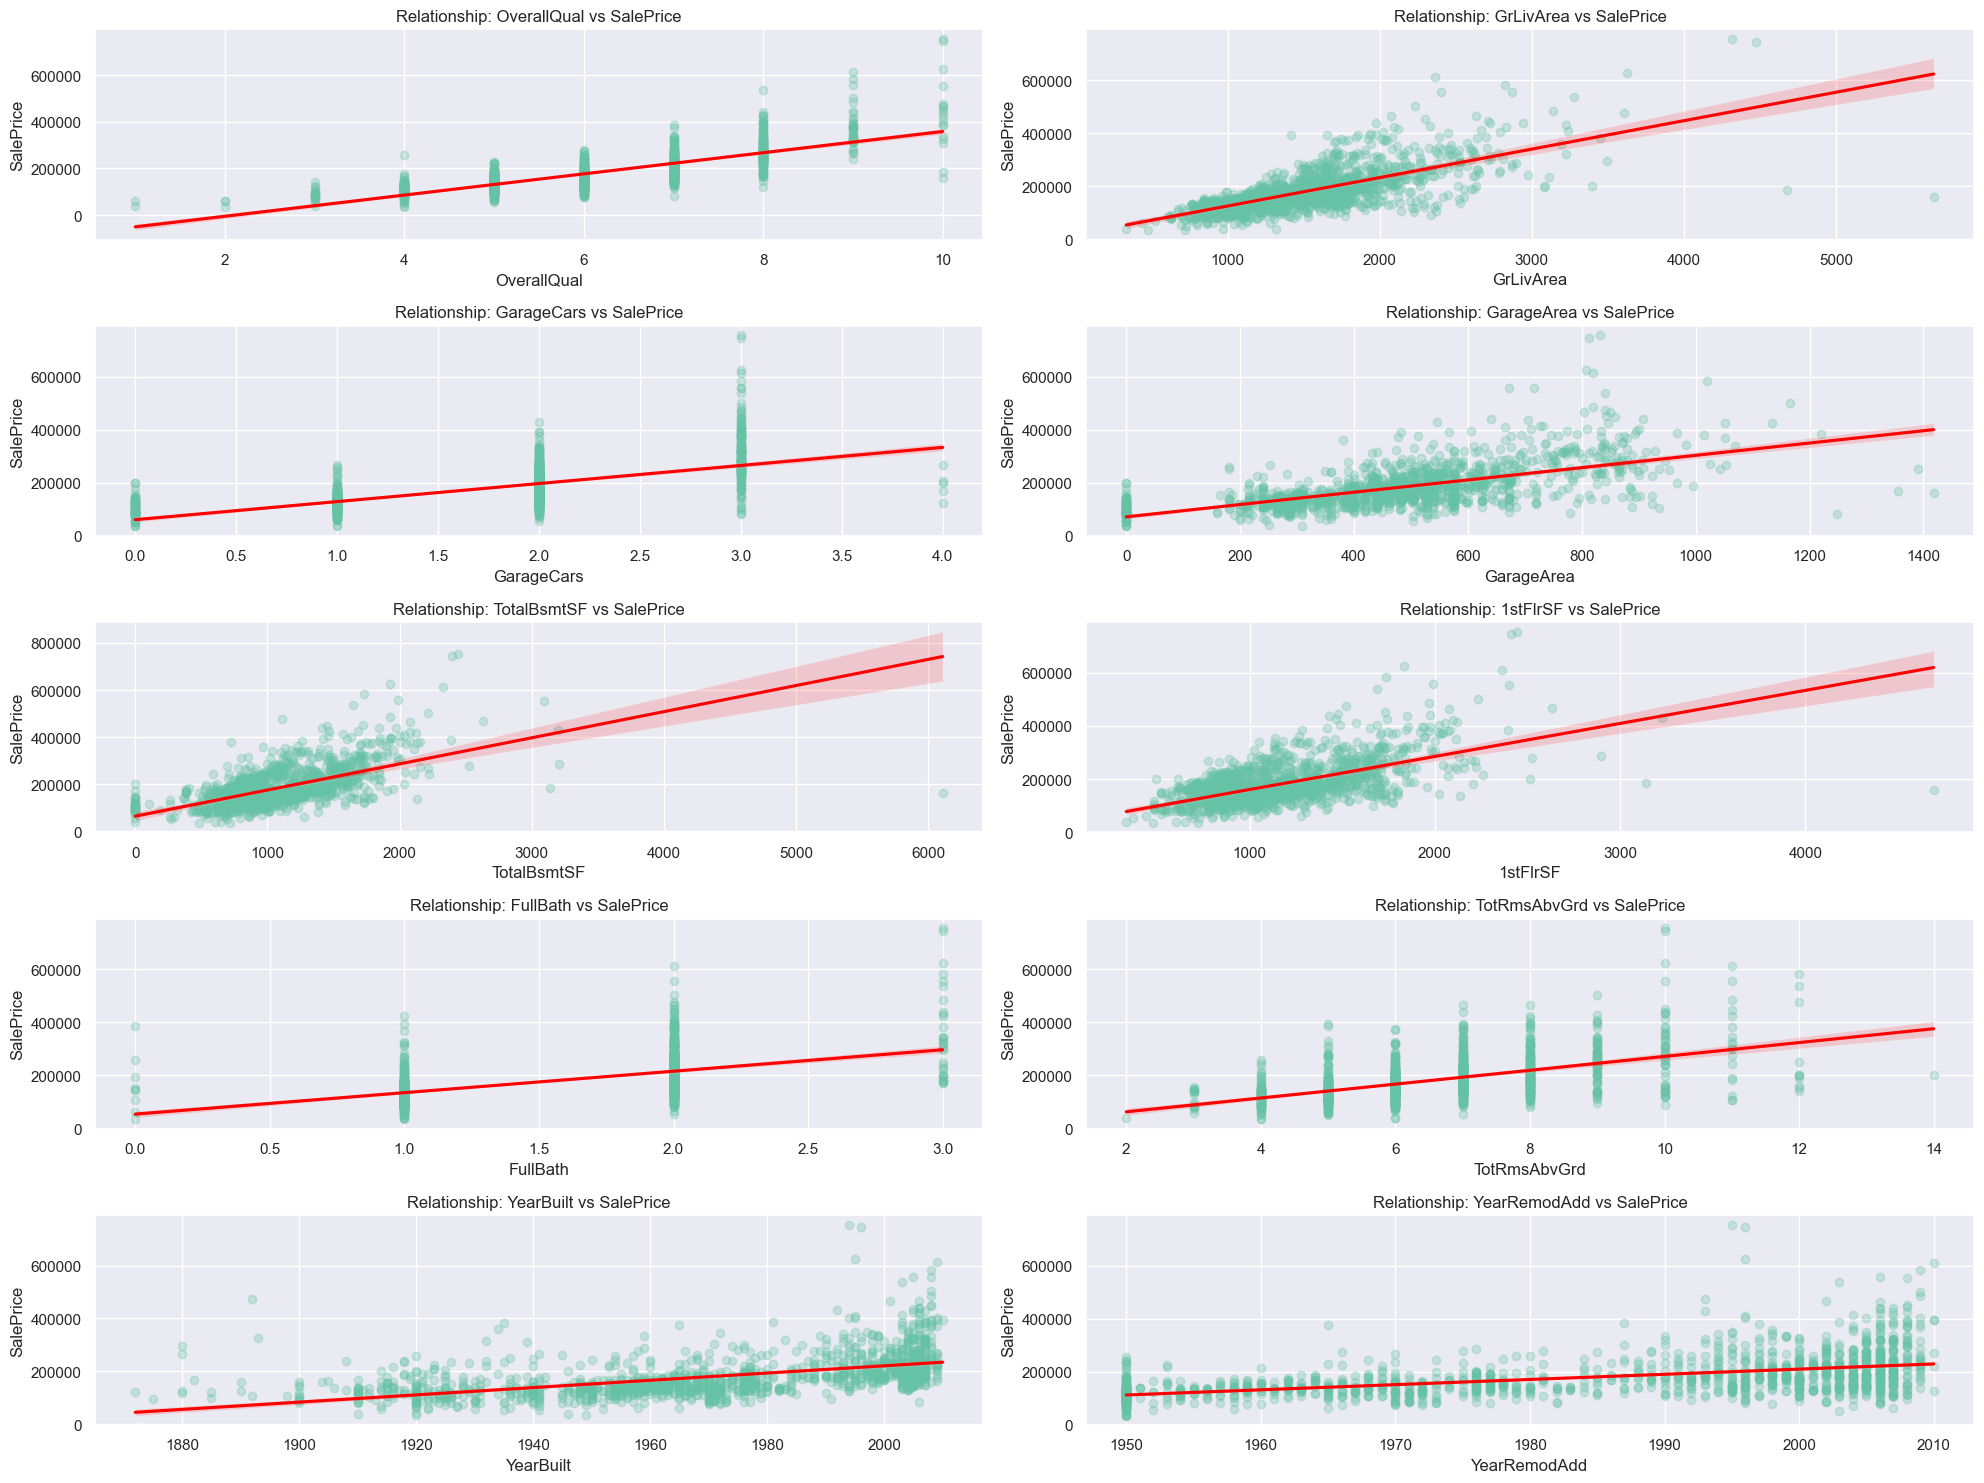

In [105]:
features = ["OverallQual", "GrLivArea", "GarageCars", "GarageArea", 
            "TotalBsmtSF", "1stFlrSF", "FullBath", "TotRmsAbvGrd", 
            "YearBuilt", "YearRemodAdd"]

plt.figure(figsize=(20, 15))

for i, col in enumerate(features):
    plt.subplot(5, 2, i + 1)
    sns.regplot(x=data[col], y=data['SalePrice'], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title(f'Relationship: {col} vs SalePrice')

plt.tight_layout()
plt.show()

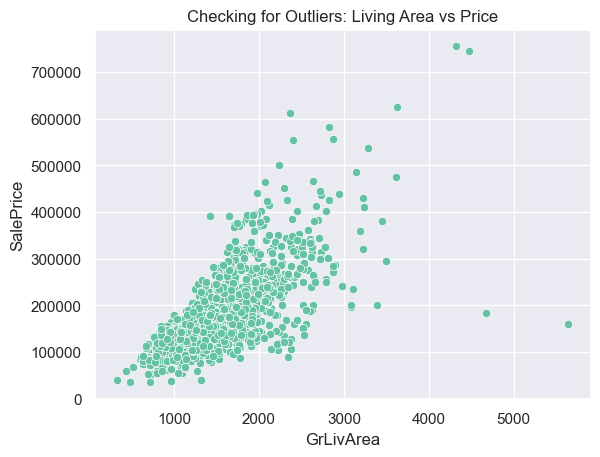

In [103]:
sns.scatterplot(x='GrLivArea', y='SalePrice', data=data)
plt.title("Checking for Outliers: Living Area vs Price")
plt.show()

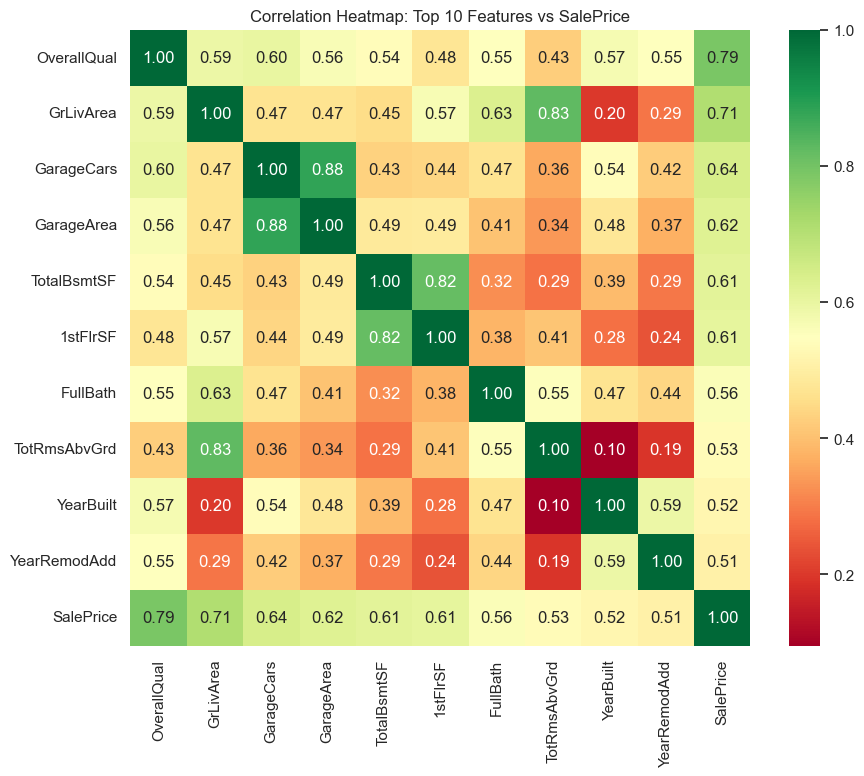

In [102]:
plt.figure(figsize=(10, 8))
sns.heatmap(data[top_10.tolist() + ['SalePrice']].corr(), 
            annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Correlation Heatmap: Top 10 Features vs SalePrice")
plt.show()

In [107]:
print(sum(data.dtypes=="object"))

43
